In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training/pituitary/Tr-pi_1354.jpg
/kaggle/input/datasets/ogprak

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [5]:
from torchvision import datasets
from torch.utils.data import ConcatDataset

train_dir = "/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Training"
test_dir  = "/kaggle/input/datasets/ogprakhar/brain-tumor-detection/Testing"
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
test_data  = datasets.ImageFolder(test_dir, transform=train_transforms)

# Combine both datasets
full_dataset = ConcatDataset([train_data, test_data])

CLASS_NAMES = train_data.classes

print("Classes:", CLASS_NAMES)
print("Total images:", len(full_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Total images: 7200


In [6]:
from torch.utils.data import random_split

dataset_size = len(full_dataset)

train_size = int(0.7 * dataset_size)
test_size  = dataset_size - train_size

train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size]
)

print("Training Images:", train_size)
print("Testing Images:", test_size)

Training Images: 5040
Testing Images: 2160


In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("DataLoaders Ready")

DataLoaders Ready


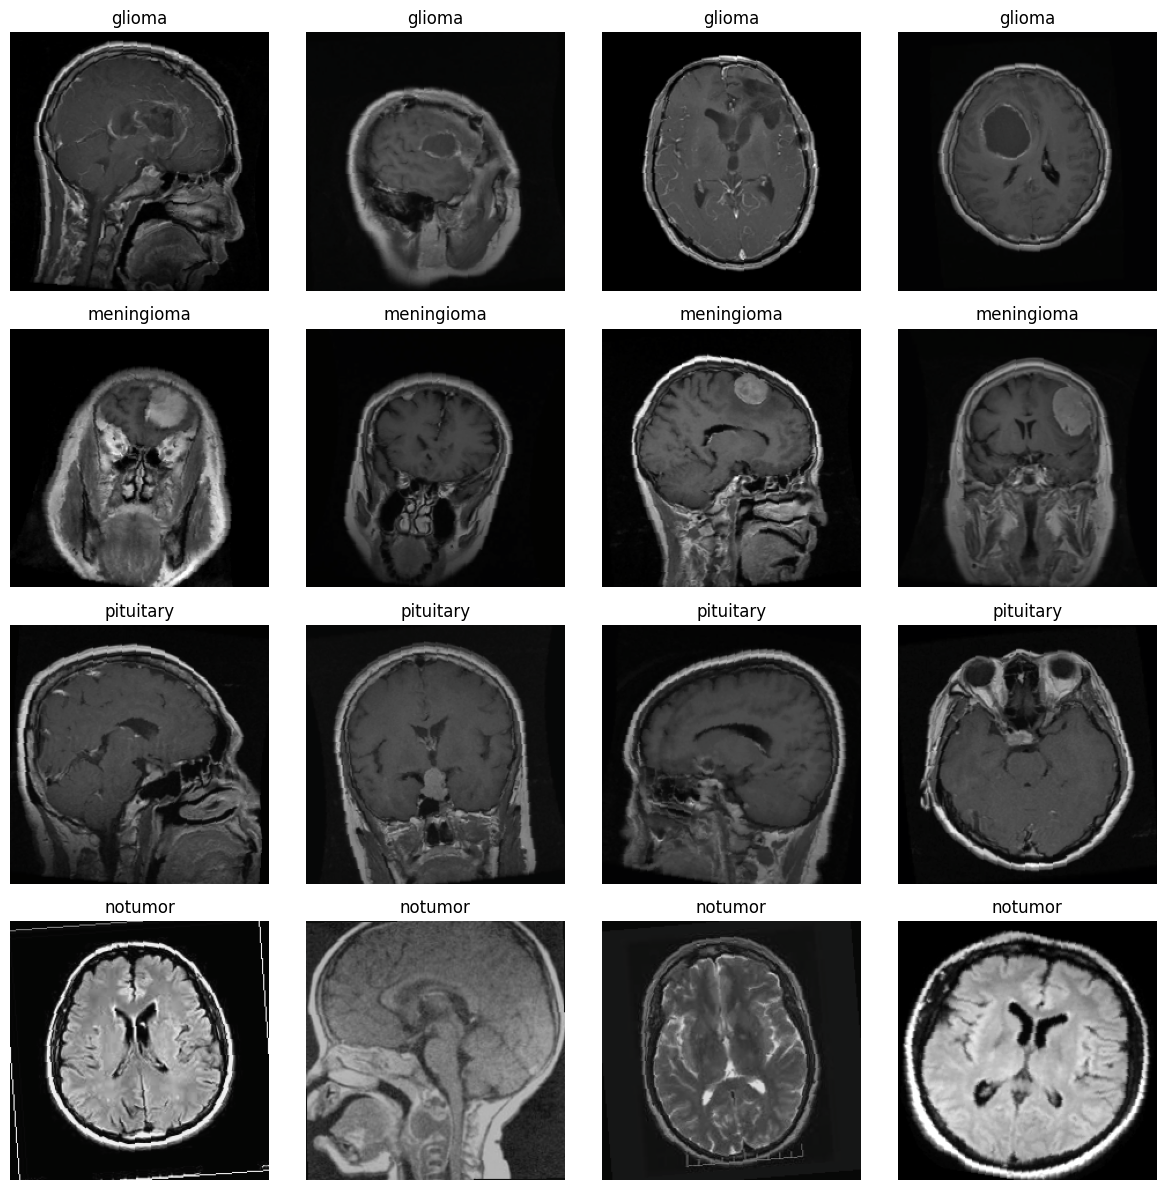

MRI visualization saved!


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Desired class order
display_order = ['glioma', 'meningioma', 'pituitary', 'notumor']

class_images = {cls: [] for cls in display_order}

for images, labels in train_loader:

    for img, label in zip(images, labels):

        class_name = CLASS_NAMES[label]

        if class_name in class_images and len(class_images[class_name]) < 4:
            class_images[class_name].append(img)

    if all(len(v) == 4 for v in class_images.values()):
        break


plt.figure(figsize=(12,12))

index = 1

for cls in display_order:

    for img in class_images[cls]:

        plt.subplot(4,4,index)

        img = img.permute(1,2,0).cpu().numpy()

        # undo normalization
        mean = np.array([0.485,0.456,0.406])
        std  = np.array([0.229,0.224,0.225])

        img = std * img + mean
        img = np.clip(img,0,1)

        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

        index += 1


plt.tight_layout()

plt.savefig("/kaggle/working/mri_samples_per_class.png", dpi=300)

plt.show()

print("MRI visualization saved!")

In [9]:
# Number of classes
NUM_CLASSES = len(CLASS_NAMES)

print("Number of Classes:", NUM_CLASSES)

# Load pretrained Vision Transformer
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)

# Modify classifier head
model.heads.head = nn.Linear(
    model.heads.head.in_features,
    NUM_CLASSES
)

model = model.to(device)

print("ViT Model Loaded")

Number of Classes: 4
ViT Model Loaded


In [10]:
import torch.optim as optim
import torch.nn as nn

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=120
)

print("Optimizer, Loss, Scheduler initialized")

Optimizer, Loss, Scheduler initialized


In [11]:
EPOCHS = 120

history = {
    "train_acc": [],
    "test_acc": [],
    "train_loss": []
}

In [12]:
EPOCHS = 120

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120)

In [14]:
import os
import torch

checkpoint_path = "/kaggle/working/checkpoint.pth"
best_model_path = "/kaggle/working/best_vit_brain_tumor.pth"

start_epoch = 0
best_acc = 0.0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    #  Safe scheduler loading
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        print(" Scheduler loaded")
    else:
        print(" Scheduler not found, using fresh scheduler")

    start_epoch = checkpoint['epoch'] + 1
    print(f" Resuming from epoch {start_epoch}")

else:
    print(" Starting fresh training")

 Scheduler loaded
✅ Resuming from epoch 2


In [15]:
import os
import torch

# PATHS
checkpoint_path = "/kaggle/working/checkpoint.pth"
best_model_path = "/kaggle/working/best_vit_brain_tumor.pth"

# LOAD CHECKPOINT
start_epoch = 0
best_acc = 0.0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        #  Safe scheduler load
        if 'scheduler_state_dict' in checkpoint:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            print(" Scheduler loaded")
        else:
            print(" Scheduler not found, using fresh scheduler")

        start_epoch = checkpoint['epoch'] + 1

    else:
        model.load_state_dict(checkpoint)

    print(f" Resuming from epoch {start_epoch}")

else:
    print("Starting fresh training")

print("Starting Training...")

# TRAIN LOOP (70% TRAIN / 30% TEST — NO VALIDATION)
for epoch in range(start_epoch, EPOCHS):

    model.train()
    correct = 0
    total = 0
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total

    history["train_acc"].append(train_acc)
    history["train_loss"].append(train_loss)

    # TESTING (your 30%)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_acc = 100 * correct / total

    history["test_acc"].append(test_acc)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Acc: {test_acc:.2f}%")

    #  SAVE BEST MODEL (based on TEST — since no validation)
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved!")

    #  SAVE CHECKPOINT
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
    }, checkpoint_path)

 Scheduler loaded
 Resuming from epoch 2
Starting Training...
Epoch [3/120] Train Acc: 71.37% | Test Acc: 75.60%
Best model saved!
Epoch [4/120] Train Acc: 80.54% | Test Acc: 83.38%
Best model saved!
Epoch [5/120] Train Acc: 84.35% | Test Acc: 86.71%
Best model saved!
Epoch [6/120] Train Acc: 84.09% | Test Acc: 84.21%
Epoch [7/120] Train Acc: 83.69% | Test Acc: 84.77%
Epoch [8/120] Train Acc: 87.66% | Test Acc: 88.33%
Best model saved!
Epoch [9/120] Train Acc: 88.61% | Test Acc: 89.12%
Best model saved!
Epoch [10/120] Train Acc: 89.96% | Test Acc: 89.54%
Best model saved!
Epoch [11/120] Train Acc: 90.89% | Test Acc: 91.02%
Best model saved!
Epoch [12/120] Train Acc: 90.63% | Test Acc: 93.47%
Best model saved!
Epoch [13/120] Train Acc: 92.12% | Test Acc: 91.06%
Epoch [14/120] Train Acc: 92.28% | Test Acc: 89.58%
Epoch [15/120] Train Acc: 93.19% | Test Acc: 91.16%
Epoch [16/120] Train Acc: 93.19% | Test Acc: 93.61%
Best model saved!
Epoch [17/120] Train Acc: 93.10% | Test Acc: 89.91%
Epo

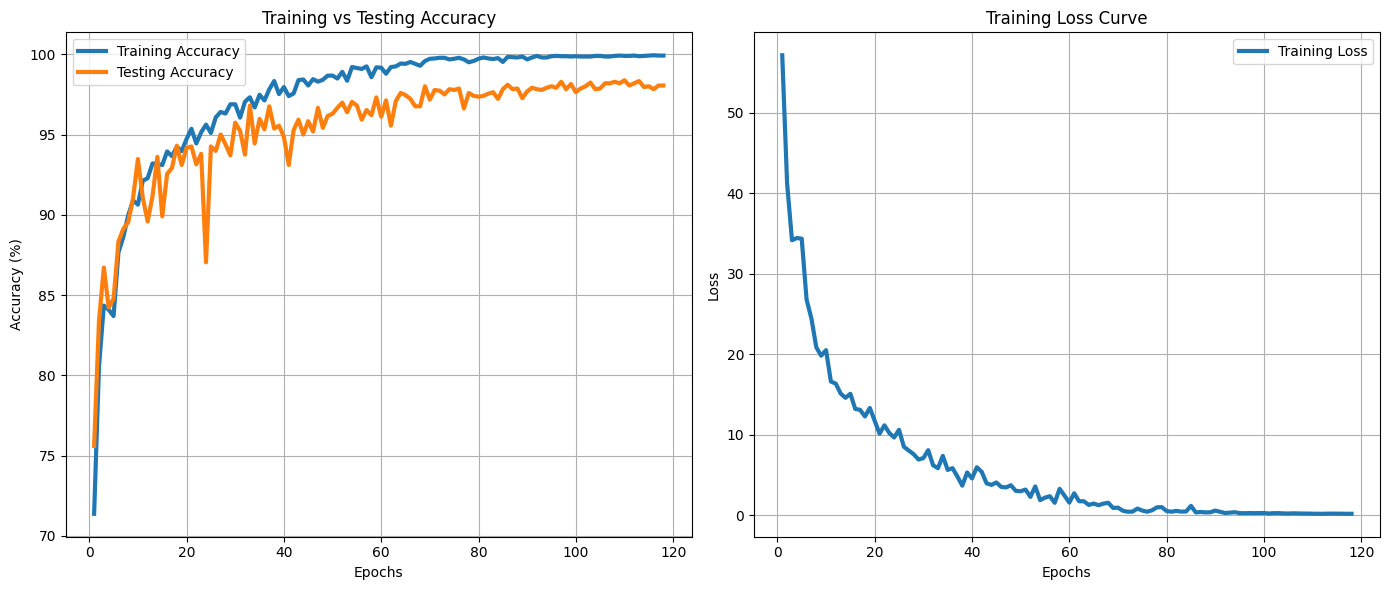

Accuracy graph saved!


In [16]:
epochs_range = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

plt.plot(epochs_range, history["train_acc"], label="Training Accuracy", linewidth=3)
plt.plot(epochs_range, history["test_acc"], label="Testing Accuracy", linewidth=3)

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Testing Accuracy")

plt.legend()
plt.grid()

plt.subplot(1,2,2)

plt.plot(epochs_range, history["train_loss"], label="Training Loss", linewidth=3)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig("/kaggle/working/accuracy_graph.png", dpi=300)

plt.show()
print("Accuracy graph saved!")

In [17]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

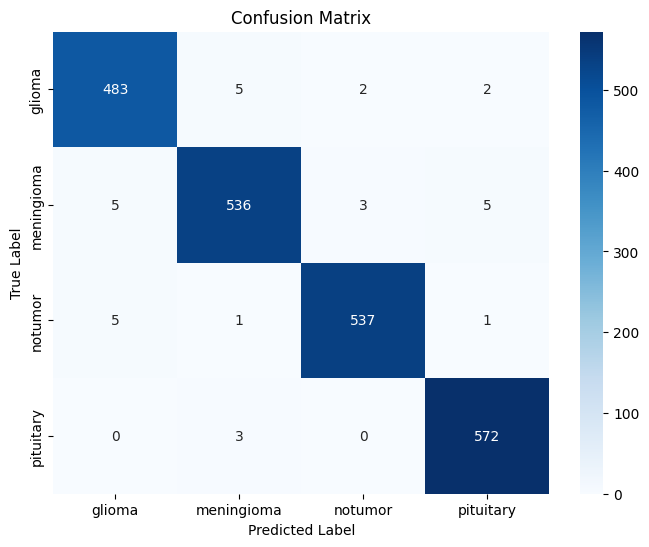

Confusion matrix saved!


In [18]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("/kaggle/working/confusion_matrix.png", dpi=300)

plt.show()

print("Confusion matrix saved!")

In [19]:
import numpy as np

sensitivity = []
specificity = []

for i in range(len(cm)):
    
    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    sens = TP / (TP + FN)
    spec = TN / (TN + FP)

    sensitivity.append(sens)
    specificity.append(spec)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

print("Average Sensitivity:", np.mean(sensitivity))
print("Average Specificity:", np.mean(specificity))

Sensitivity: [np.float64(0.9817073170731707), np.float64(0.97632058287796), np.float64(0.9871323529411765), np.float64(0.9947826086956522)]
Specificity: [np.float64(0.9940047961630696), np.float64(0.994413407821229), np.float64(0.9969059405940595), np.float64(0.9949526813880126)]
Average Sensitivity: 0.9849857153969899
Average Specificity: 0.9950692064915927


In [20]:
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(all_labels, all_preds) * 100

print("Accuracy:", accuracy)

print(classification_report(
    all_labels,
    all_preds,
    target_names=CLASS_NAMES
))

Accuracy: 98.51851851851852
              precision    recall  f1-score   support

      glioma       0.98      0.98      0.98       492
  meningioma       0.98      0.98      0.98       549
     notumor       0.99      0.99      0.99       544
   pituitary       0.99      0.99      0.99       575

    accuracy                           0.99      2160
   macro avg       0.99      0.98      0.99      2160
weighted avg       0.99      0.99      0.99      2160



In [21]:
# Load model (if not already)
model.load_state_dict(torch.load("/kaggle/working/best_vit_brain_tumor.pth"))
model.eval()
model.to(device)

#  DEFINE TARGET LAYER (IMPORTANT)
target_layers = [model.encoder.layers[-1].ln_1]

print(" Target layer defined!")

 Target layer defined!


In [22]:
!pip install grad-cam -q

import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print(" Grad-CAM Ready!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 36.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
 Grad-CAM Ready!


In [23]:
torch.save(model.state_dict(), "/kaggle/working/best_vit_brain_tumor.pth")
print(" Model saved successfully!")

 Model saved successfully!


In [24]:
import os
print(os.listdir("/kaggle/working"))

['checkpoint.pth', 'confusion_matrix.png', 'accuracy_graph.png', '.virtual_documents', 'mri_samples_per_class.png', 'best_vit_brain_tumor.pth']


In [25]:
import os
print(os.listdir("/kaggle/working"))

['checkpoint.pth', 'confusion_matrix.png', 'accuracy_graph.png', '.virtual_documents', 'mri_samples_per_class.png', 'best_vit_brain_tumor.pth']


In [26]:
model.load_state_dict(torch.load("/kaggle/working/best_vit_brain_tumor.pth"))
model.eval()
model.to(device)

print(" Model Loaded!")

 Model Loaded!


In [27]:
def reshape_transform(tensor, height=14, width=14):
    # Remove CLS token
    result = tensor[:, 1:, :]
    
    # Reshape
    result = result.reshape(tensor.size(0), height, width, tensor.size(2))
    
    # Convert to CNN format
    result = result.permute(0, 3, 1, 2)
    
    return result

print(" Reshape transform ready!")

 Reshape transform ready!


In [28]:
# Custom display order (notumor last)
DISPLAY_CLASSES = ['glioma', 'meningioma', 'pituitary', 'notumor']

In [29]:
sample_images_raw = {}
sample_images_tensor = {}

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

for images, labels in test_loader:
    for img, lbl in zip(images, labels):
        cls = CLASS_NAMES[lbl.item()]

        if cls not in sample_images_raw:
            raw = inv_normalize(img).permute(1,2,0).numpy()
            raw = np.clip(raw, 0, 1).astype(np.float32)

            sample_images_raw[cls] = raw
            sample_images_tensor[cls] = img

        if len(sample_images_raw) == 4:
            break
    if len(sample_images_raw) == 4:
        break

print(" Samples collected:")
for cls in DISPLAY_CLASSES:
    print(f"{cls} ")

 Samples collected:
glioma 
meningioma 
pituitary 
notumor 


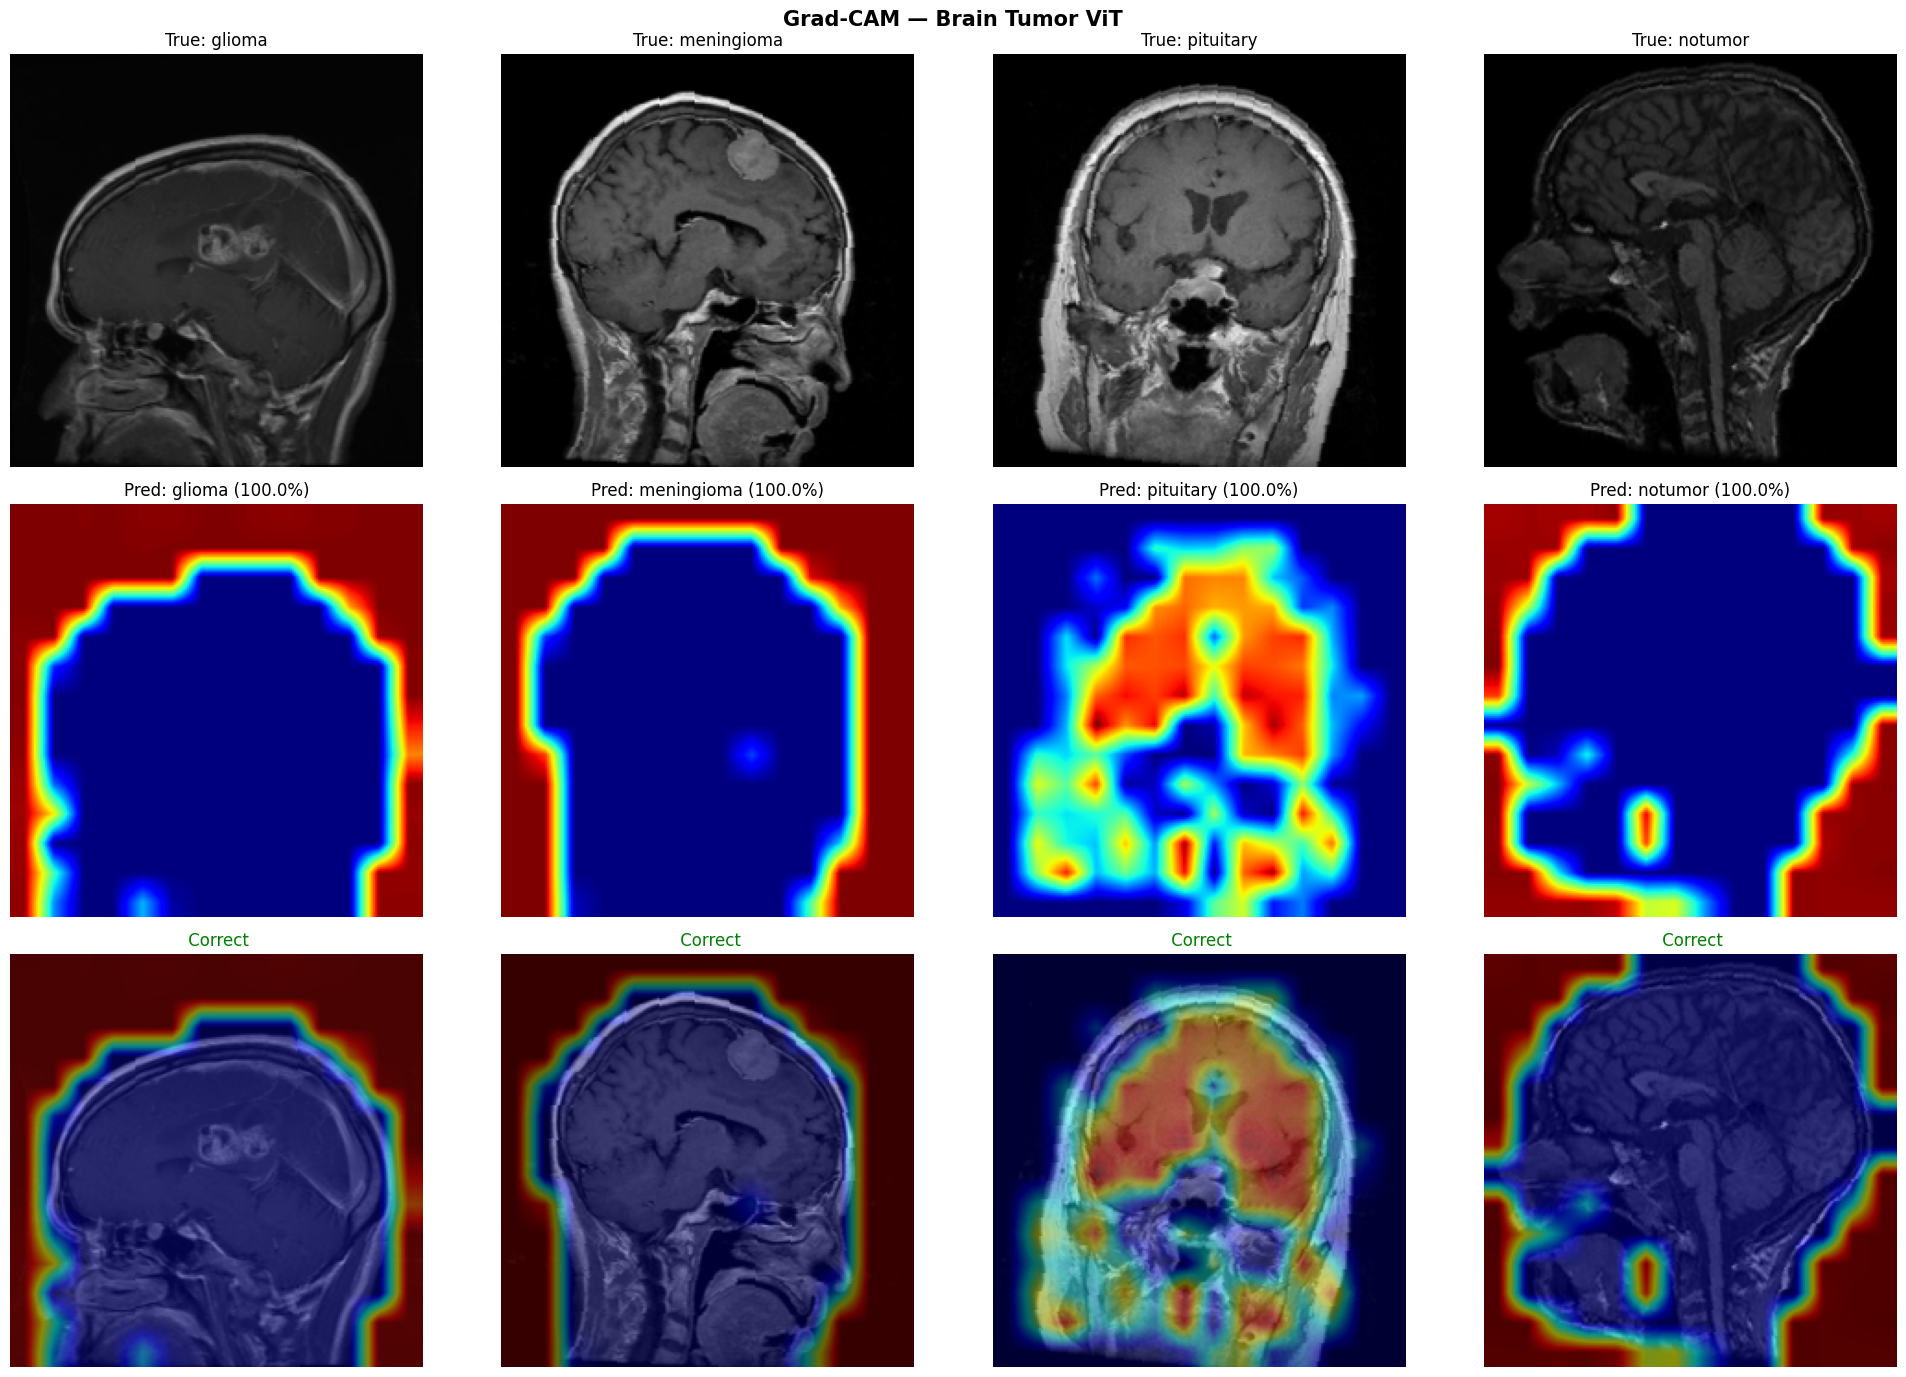

In [30]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))

row_titles = ['Original MRI', 'Grad-CAM Heatmap', 'Overlay']

with GradCAM(model=model,
             target_layers=target_layers,
             reshape_transform=reshape_transform) as cam:

    for idx, cls_name in enumerate(DISPLAY_CLASSES):

        img_tensor = sample_images_tensor[cls_name].unsqueeze(0).to(device)
        img_raw = sample_images_raw[cls_name]

        with torch.no_grad():
            output = model(img_tensor)
            pred_idx = output.argmax(1).item()
            pred_cls = CLASS_NAMES[pred_idx]
            confidence = F.softmax(output, dim=1)[0][pred_idx].item() * 100

        targets = [ClassifierOutputTarget(pred_idx)]
        grayscale = cam(input_tensor=img_tensor, targets=targets)[0]

        overlay = show_cam_on_image(img_raw, grayscale, use_rgb=True, image_weight=0.6)

        axes[0, idx].imshow(img_raw)
        axes[0, idx].set_title(f"True: {cls_name}")
        axes[0, idx].axis('off')

        axes[1, idx].imshow(grayscale, cmap='jet')
        axes[1, idx].set_title(f"Pred: {pred_cls} ({confidence:.1f}%)")
        axes[1, idx].axis('off')

        axes[2, idx].imshow(overlay)
        axes[2, idx].set_title(
            " Correct" if cls_name == pred_cls else " Wrong",
            color='green' if cls_name == pred_cls else 'red'
        )
        axes[2, idx].axis('off')

# Row labels
for row, title in enumerate(row_titles):
    axes[row, 0].set_ylabel(title, fontsize=12, fontweight='bold')

plt.suptitle("Grad-CAM — Brain Tumor ViT", fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig("/kaggle/working/gradcam_results.png", dpi=300)
plt.show()

In [31]:
plt.savefig("/kaggle/working/gradcam_results.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [32]:
wrong_images = {}

model.eval()

for images, labels in test_loader:   #  FIXED
    preds = model(images.to(device)).argmax(1).cpu()

    for img, true_lbl, pred_lbl in zip(images, labels, preds):
        if true_lbl != pred_lbl:
            cls = CLASS_NAMES[true_lbl.item()]
            
            if cls not in wrong_images:
                wrong_images[cls] = (img, pred_lbl.item())

        if len(wrong_images) == 4:
            break
    if len(wrong_images) == 4:
        break

if len(wrong_images) == 0:
    print(" No wrong predictions!")

In [33]:
torch.save(model.state_dict(), "/kaggle/working/vit_brain_tumor_model.pth")